# Univariate Analysis

In [1]:
import pandas as pd

df = pd.read_csv("customer_churn.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


## Numerical Analysis

### 1. Mean
The arithmetic average of a numerical variable, calculated by summing all values and dividing by the total count.

Example: 

Calculating the average monthly charge for a telecom subscription base.

#### AI/ML Usage: 

Used in data standardization and baseline model prediction (e.g., predicting the mean for regression baseline).

In [2]:
mean_val = df['MonthlyCharges'].mean()
print(f"Mean Monthly Charges: {mean_val:.2f}")

Mean Monthly Charges: 70.09


### 2. Median
The middle value of an ordered dataset (50th percentile) that splits data into two equal halves.

Example:

Determining median house price in a city to prevent multi-million dollar mansions from distorting the "typical" price.

#### AI/ML Usage

Used for robust missing value imputation when features contain significant outliers or skewed distributions.

In [3]:
median_val = df['MonthlyCharges'].median()
print(f"Median Monthly Charges: {median_val:.2f}")

Median Monthly Charges: 70.16


### 3. Mode
The most frequently occurring individual value in a dataset.

Example: 

Finding that a 1-month tenure is the most common account age among churned customers.

#### AI/ML Usage

Primary method for imputing missing values in categorical or discrete numerical features.

In [4]:
mode_val = df['TenureYears'].mode()[0]
print(f"Most Frequent Tenure: {mode_val}")

Most Frequent Tenure: 6


### 4. Minimum & Maximum
The smallest (Minimum) and largest (Maximum) observed numerical values within a feature.

Example: 

Identifying the youngest customer age (18) and oldest customer age (80) in a demographic survey.

#### AI/ML Usage

Used to calculate feature ranges and perform Min-Max Scaling (scaling features into a $[0, 1]$ interval).

In [5]:
min_val = df['TotalCharges'].min()
max_val = df['TotalCharges'].max()
print(f"Range Bounds: Min = {min_val}, Max = {max_val}")

Range Bounds: Min = 29.35, Max = 15559.29


### 5. Range

The absolute numerical difference between the maximum and minimum values 

($\text{Range} = \text{Max} - \text{Min}$)

Example:

Measuring the total spread between the lowest ($18.25) and highest ($118.75) monthly rate plans.

#### AI/ML Usage

Provides a rapid check for overall feature dispersion and scale bounds prior to model feature engineering.

In [6]:
range_val = df['MonthlyCharges'].max() - df['MonthlyCharges'].min()
print(f"Monthly Charges Range: {range_val:.2f}")

Monthly Charges Range: 99.96


### 6. Variance

The average of squared deviations from the mean ($\sigma^2$), measuring overall data dispersion.

Example:

Assessing variability in customer session durations to evaluate user engagement stability.

#### AI/ML Usage

Core metric in Principal Component Analysis (PCA) to identify direction vectors that capture maximum feature variance.

In [7]:
variance_val = df['MonthlyCharges'].var()
print(f"Variance: {variance_val:.2f}")

Variance: 832.48


### 7. Standard Deviation

The square root of variance ($\sigma$), measuring data spread in the same original units as the variable.

Example:

Evaluating risk volatility in daily transaction amounts for fraud detection systems.

#### AI/ML Usage

Used in standard feature scaling ($Z = \frac{X - \mu}{\sigma}$) and defining anomaly thresholds (e.g., values $> 3\sigma$).

In [8]:
std_val = df['MonthlyCharges'].std()
print(f"Standard Deviation: {std_val:.2f}")

Standard Deviation: 28.85


### 8. Quartiles & Percentiles

Values dividing ordered data into 100 equal parts (Percentiles) or 4 equal parts (Quartiles: $Q_1 = 25\%$, $Q_2 = 50\%$, $Q_3 = 75\%$).

Example:

Identifying the $90^{\text{th}}$ percentile of network bandwidth usage to set server capacity limits.

#### AI/ML Usage

Interquartile Range ($\text{IQR} = Q_3 - Q_1$) is used to define upper ($Q_3 + 1.5 \times \text{IQR}$) and lower bounds for outlier removal.

In [9]:
iqr = df['MonthlyCharges'].quantile([0.25, 0.50, 0.75, 0.90])
print(iqr)

0.25     45.9200
0.50     70.1650
0.75     94.9575
0.90    109.5610
Name: MonthlyCharges, dtype: float64


### 9. Skewness
A measure of asymmetry in a distribution around its mean. Positive skew indicates a long right tail; negative skew indicates a long left tail.

Example: 

Customer Lifetime Value (CLV) is usually right-skewed, as a majority spend modestly while a few spend high amounts.

#### AI/ML Usage

High skewness harms linear regression and distance-based algorithms; signals the need for Log, Square Root, or Box-Cox transformations.

In [10]:
skew_val = df['TotalCharges'].skew()
print(f"Skewness: {skew_val:.2f}")

Skewness: 0.80


### 10. Kurtosis
A measure of the "tailedness" or extreme value frequency relative to a normal distribution. High kurtosis means heavy tails (frequent extreme outliers).

Example: 

Financial market return distributions exhibiting heavy tails during sudden economic crashes.

#### AI/ML Usage

High kurtosis warns that distance algorithms will be heavily distorted by extreme values, suggesting robust estimators or tree-based models.


In [11]:
kurt_val = df['TotalCharges'].kurt()
print(f"Kurtosis: {kurt_val:.2f}")

Kurtosis: -0.14


### 11. Histogram

A visual display of continuous numeric data grouped into discrete intervals (bins) showing frequency counts.

Example: 

Visualizing how customer account ages (tenure) are distributed from 0 to 72 months.

### AI/ML Usage

Used during EDA to inspect data shape, identify multi-modal distributions, and choose appropriate binning strategies.

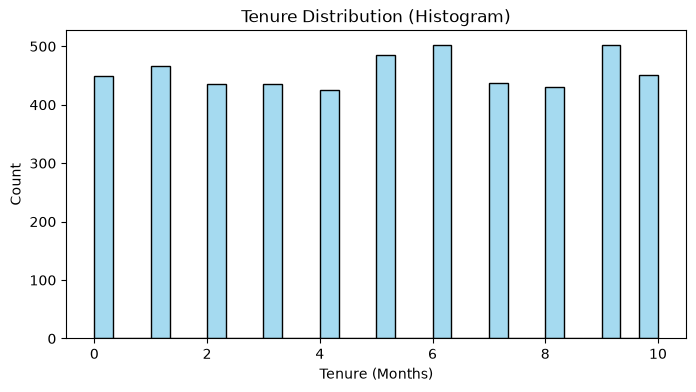

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['TenureYears'], bins=30, kde=False, color='skyblue')
plt.title('Tenure Distribution (Histogram)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

### 12. KDE / Density Plot

Kernel Density Estimation (KDE) produces a smoothed continuous probability density function curve of a continuous variable.

Example: 

Overlaying smooth probability distributions of monthly spend between churned vs. retained customers.

#### AI/ML Usage

Helps verify if a feature meets normality assumptions required by parametric algorithms (e.g., Linear Discriminant Analysis).

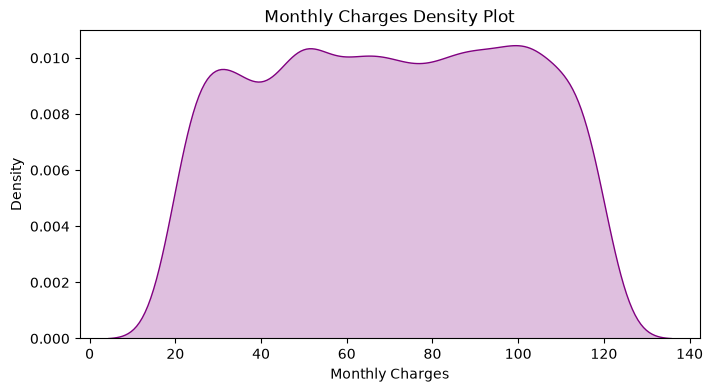

In [13]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df['MonthlyCharges'], fill=True, color='purple')
plt.title('Monthly Charges Density Plot')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.show()

### 13. Box Plot

A graphic displaying $Q_1$, Median, $Q_3$, along with whiskers and individual data points classified as potential outliers based on $1.5 \times \text{IQR}$.

Example: 

Comparing payment distribution spreads across different customer contract tiers.

#### AI/ML Usage

The primary visual tool for detecting univariate anomalies before model training.

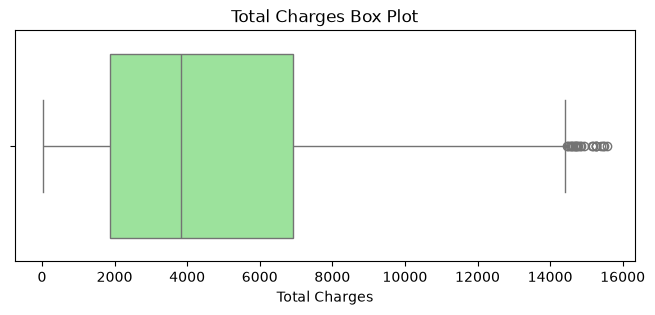

In [14]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['TotalCharges'], color='lightgreen')
plt.title('Total Charges Box Plot')
plt.xlabel('Total Charges')
plt.show()

## Categorical Analysis

### 1. Frequency

The absolute raw count of observations belonging to each distinct category within a discrete variable.

Example: 

Counting that 1,308 customers pay via Mailed Check in a customer database.

#### AI/ML Usage

Ensures each feature level has sufficient representative data points before splitting data into training and validation sets.

In [15]:
freq = df['PaymentMethod'].value_counts()
print(freq)

PaymentMethod
Mailed check        1308
Credit card         1261
Bank transfer       1248
Electronic check    1203
Name: count, dtype: int64


### 2. Unique Values

The total number of distinct, non-duplicate category levels present in a variable.

Example:

Identifying that the InternetService column contains categories like DSL, Fiber optic, and No service.

#### AI/ML Usage

Determines feature cardinality to select appropriate encoding strategies (e.g., One-Hot Encoding for low cardinality vs. Target Encoding for high cardinality).

In [16]:
num_unique = df['ContractType'].nunique()
categories = df['ContractType'].unique()
print(f"Unique Count: {num_unique} | Categories: {categories}")

Unique Count: 4 | Categories: <ArrowStringArray>
['One year', 'Two year', 'Month-to-month', 'Month to month']
Length: 4, dtype: str


### 3. Value Counts

A tabular output mapping every unique categorical value directly to its corresponding absolute occurrence count.

Example: 

Generating a complete summary table of customer counts across all contract types.

#### AI/ML Usage

Used during data cleaning to spot rare categories (< 1% representation) or data entry typos that require consolidation.

In [17]:
value_counts_series = df['InternetService'].value_counts(dropna=False)
print(value_counts_series)

InternetService
Fiber optic    2253
DSL            1734
No             1032
fiber optic       1
Name: count, dtype: int64


### 4. Percentage Distribution
The relative fraction of total observations represented by each category, expressed as a percentage:

$$\text{Percentage} = \left(\frac{\text{Category Frequency}}{N}\right) \times 100$$

Example:

Calculating that 27.83% of the subscriber base has churned.

#### AI/ML Usage

Evaluates class balance in target variables to determine if class-weighting or resampling (e.g., SMOTE) is necessary for model training.

In [18]:
pct_dist = df['Churn'].value_counts(normalize=True) * 100
print(pct_dist.round(2))

Churn
No     72.17
Yes    27.83
Name: proportion, dtype: float64


### 5. Bar Chart

A chart displaying rectangular bars where the length or height of each bar corresponds to an aggregated continuous summary metric (e.g., mean, sum) across categories.

Example:

Visualizing the average monthly charge across different contract types.

#### AI/ML Usage

Used in exploratory analysis to evaluate bivariate relationships between categorical predictors and continuous target variables.



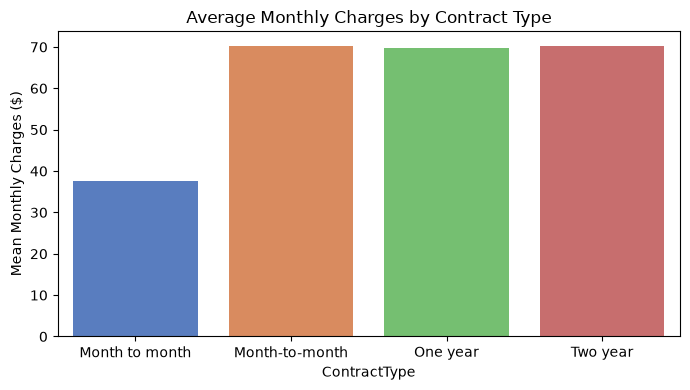

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
contract_avg = df.groupby('ContractType')['MonthlyCharges'].mean().reset_index()
sns.barplot(
    data=contract_avg,
    x='ContractType',
    y='MonthlyCharges',
    hue='ContractType',
    legend=False,
    palette='muted'
)
plt.title('Average Monthly Charges by Contract Type')
plt.ylabel('Mean Monthly Charges ($)')
plt.tight_layout()
plt.show()

### 6. Count Plot
A specialized bar chart where the height of each bar directly reflects the raw frequency count of records in each category.

Example: 

Comparing the absolute volume of users across all payment options.

#### AI/ML Usage

Provides visual confirmation of category distributions and imbalances across features.

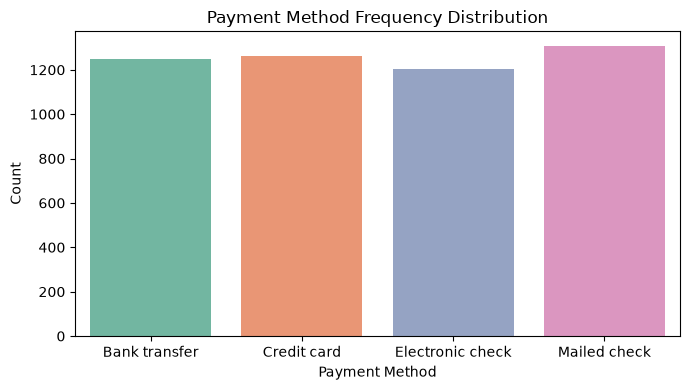

In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='PaymentMethod',
    legend=False,
    palette='Set2')
plt.title('Payment Method Frequency Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 7. Pie Chart

A circular chart divided into proportional slices representing percentage shares of a whole (100%).

Example: 

Presenting the overall percentage breakdown of active vs. churned customers in executive dashboards.

#### AI/ML Usage

Best suited for low-cardinality binary or ternary target variables ($\le 3$ categories) to communicate baseline class ratios.

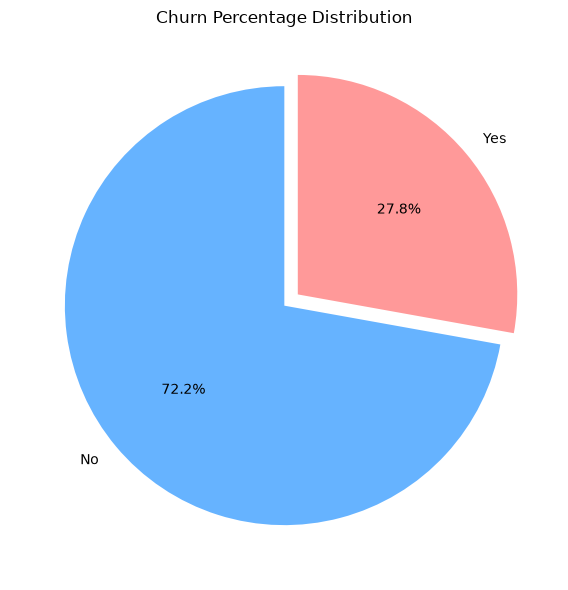

In [21]:
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.08))
plt.title('Churn Percentage Distribution')
plt.tight_layout()
plt.show()